In [1]:
#Import data manipulation
import pandas as pd # data processing, CSV file
import numpy as np#Linear algebra
import os

In [2]:
#Import data Visualization package
import matplotlib.pyplot as plt
import seaborn as sns

#Import the warnings library
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns',35)   #displays 35 columns 

In [4]:
#Load the dataset
df=pd.read_csv("/kaggle/input/datasets/anushagonepatla/hr-employee-attrition/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape 

(1470, 35)

In [6]:
#checking duplicates
duplicates= df.duplicated().sum()
print(duplicates)

0


In [7]:
df.isnull().sum()/len(df)*100   #len(df)*100 shows in percentage 

Age                         0.0
Attrition                   0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtC

#len(df)*100=missing values percentage column
len(df)=total number of rows in dataset
*100=percentage


In [8]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Based on the summary, there are no apparent outliers in the dataset, as the values fall within expected ranges.

**Exploratory Data Analysis(EDA)**

In [10]:
df.head() #It takes first few rows by default

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


**Attrition Rate**

The attrition rate measures the percentage of employees who leave the company in a given period of time. It is usually calculated within a year and is expressed as a percentage of the total number of employees.

In [11]:
attrition= df['Attrition'].value_counts(normalize=True)
print(attrition)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


Here,the output displays the proportion of employees with regard to attrition status in the dataset.

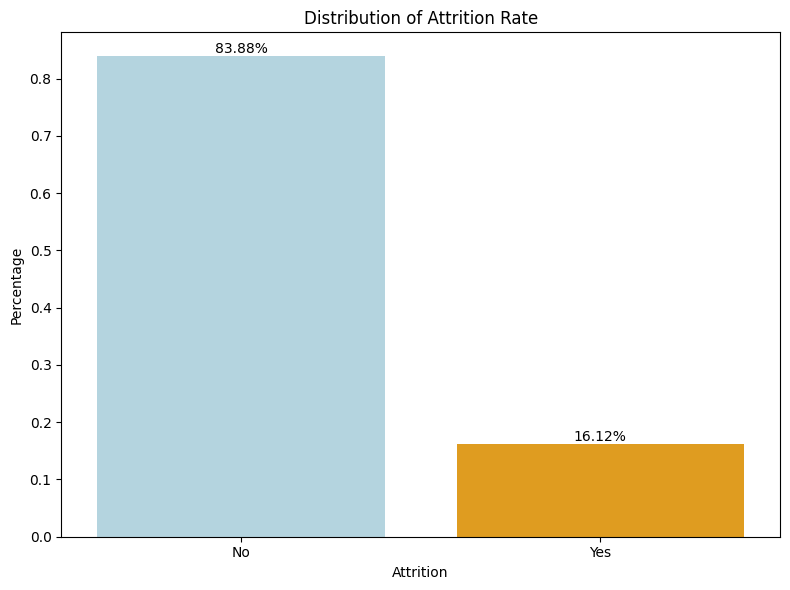

In [12]:
#let's Visualize:

plt.figure(figsize=(8,6))
ax=sns.barplot(x=attrition.index,y=attrition,palette=['lightblue','Orange'])

for p in ax.patches:
  ax.annotate(f'{p.get_height()*100:.2f}%',#Format number as percentage
              (p.get_x()+p.get_width()/2., #Decides where the text should appear
               p.get_height()),#places on top of the bar
              ha='center',va='bottom')#horizantal and vertical alignment

plt.title('Distribution of Attrition Rate')
plt.xlabel('Attrition')
plt.ylabel('Percentage')
plt.tight_layout()

plt.show()

**Observation:** 
Based on the analysis the companies attrition is 16.12% and this means that about 16.12% of the employees decided to leave the company during the analyzed period.

**Average of Tenure**
The average tenure measures the average number of years an employee stays with the company before leaving.It can provide insight into workforce stability and employees satisfaction within the organization.

In [13]:
avg_tenure=df['YearsAtCompany'].mean()

print(f'Average years of employee to leave the company is {avg_tenure} years')

Average years of employee to leave the company is 7.0081632653061225 years


The employees before they decided to leave the average tenure is 7 years, so it can be concluded that many employees feel comfortable and have been with the company for a long time.

**Employee Demographics**

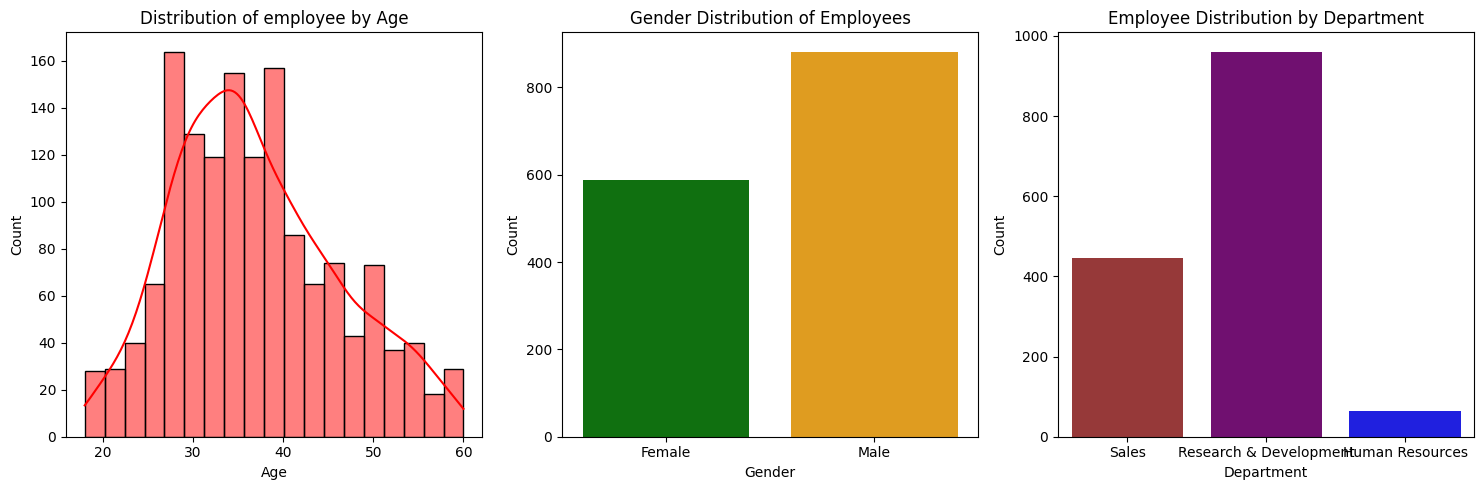

In [14]:
#Distribution of Gender,Age and Department using Histrogram and count plot.

fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,5))

sns.histplot(data=df,x='Age',kde=True,color='red',ax=axes[0])
axes[0].set_title('Distribution of employee by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.countplot(data=df,x='Gender',palette=['green','orange'],ax=axes[1])
axes[1].set_title('Gender Distribution of Employees')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

sns.countplot(data=df,x='Department',palette=['brown','purple','blue'],ax=axes[2])
axes[2].set_title('Employee Distribution by Department')
axes[2].set_xlabel('Department')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Observation**
1.Age: Most of the companies employees are in the 30-40 age group.This indicates that the company has many employees who are at a productive and experience age.

2:Gender: The majority [of employees at this company are male.There are significantly more male employees than female employees.

3:Department: Most of the company employees are concentrated in the research and development department.This indicates that the company is heavily focused on product or service research and development activites.

In [15]:
df_attrition=df[df['Attrition']=='Yes']

df_attrition.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
14,28,Yes,Travel_Rarely,103,Research & Development,24,3,Life Sciences,1,19,3,Male,50,2,1,Laboratory Technician,3,Single,2028,12947,5,Y,Yes,14,3,2,80,0,6,4,3,4,2,0,3
21,36,Yes,Travel_Rarely,1218,Sales,9,4,Life Sciences,1,27,3,Male,82,2,1,Sales Representative,1,Single,3407,6986,7,Y,No,23,4,2,80,0,10,4,3,5,3,0,3
24,34,Yes,Travel_Rarely,699,Research & Development,6,1,Medical,1,31,2,Male,83,3,1,Research Scientist,1,Single,2960,17102,2,Y,No,11,3,3,80,0,8,2,3,4,2,1,3


**Demographic Factors**

In [16]:
#Function to calculate attrition rate or Fungsi untuk Menghitung
def calculate_attrition_rate(df,column):
    attrition_counts=df.groupby([column,'Attrition']).size().unstack().reindex(columns=['Yes','No'],fill_value=0)
    
    attrition_rate=attrition_counts['Yes']/attrition_counts.sum(axis=1)*100
    
    attrition_rate_df=attrition_rate.reset_index()
    attrition_rate_df.columns=[column,'AttritionRate']
    
    return attrition_rate_df

It Calculates attrition percentage grouped by a specified column using groupby,unstacking the data, and computing the ratio of employees who left to total employees.

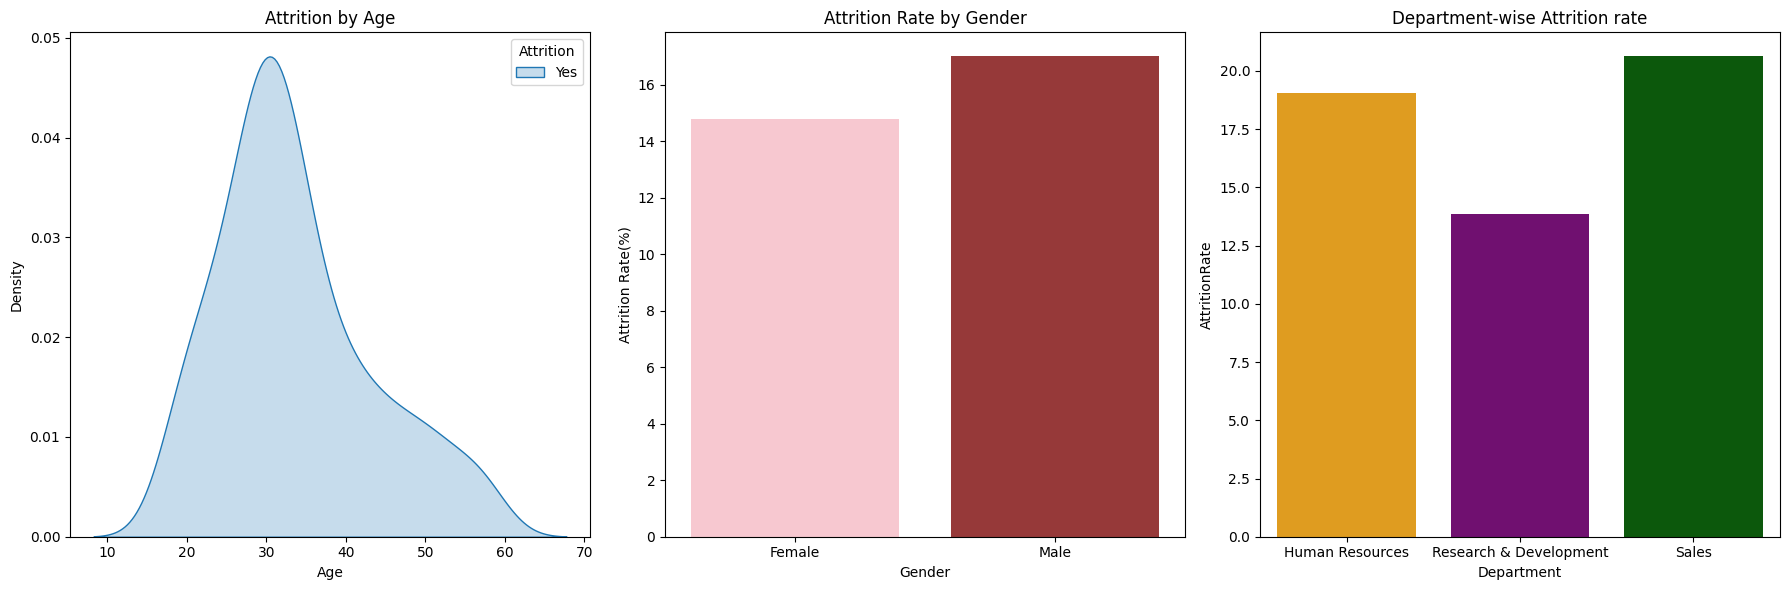

In [17]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(18,6))
#KDE plot of Age with Attrition hue
sns.kdeplot(data=df_attrition,x='Age',hue='Attrition',fill=True,color='orange',ax=axes[0])
axes[0].set_title('Attrition by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')

#Bar plot of Gender count with Attrition hue
attrition_rate_df=calculate_attrition_rate(df,'Gender')
sns.barplot(data=attrition_rate_df,x='Gender',y='AttritionRate',palette=['Pink','Brown'],ax=axes[1])
axes[1].set_title('Attrition Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Attrition Rate(%)')

#Department-wise attrition rate
attrition_dept_df=calculate_attrition_rate(df,'Department')
sns.barplot(data=attrition_dept_df,x='Department',y='AttritionRate',palette=['Orange','Purple','Darkgreen'],ax=axes[2])
axes[2].set_title('Department-wise Attrition rate')
axes[2].set_xlabel('Department')
axes[2].set_ylabel('AttritionRate')

plt.tight_layout()
plt.show()

**Behavioral Staisfaction-related variables**



In [18]:
#Method1 : Using map function and forloop 
#Changing the map location from 1,2,3,4 to low,medium,high,vry high.

rating_map={
    1:'Low',
    2:'Medium',
    3:'High',
    4:'Very High'
}

rating_columns=['JobSatisfaction',
                'WorkLifeBalance',
                'EnvironmentSatisfaction',
                'JobInvolvement']

for col in rating_columns:                 #using for loop so that we can define all columns at once.
    df[col] = df[col].map(rating_map)

education_map={
            1:'Below College',      # education is taken saperately because it has values different like,Bachelor,Masters,Below College..
            2:'College',
            3:'Bachelor',
            4:'Master',
            5:'Doctor'
}

df['Education']=df['Education'].map(education_map)
order=['Low','Medium','High','Very High']

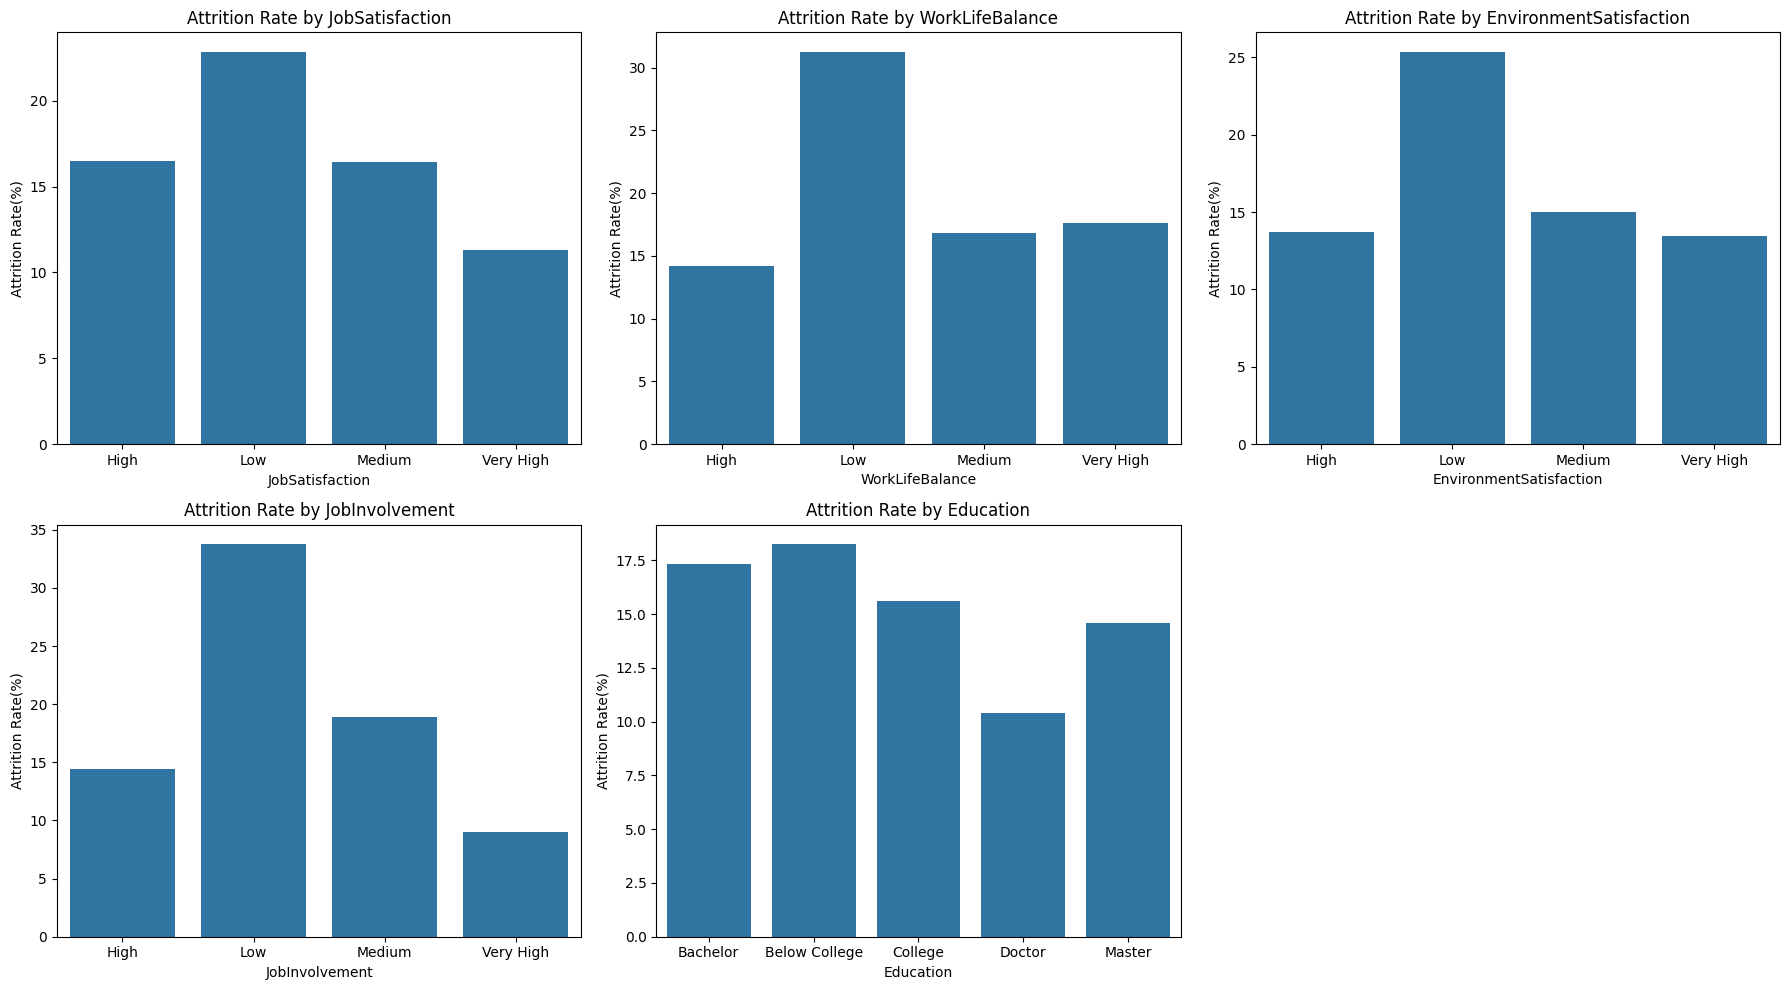

In [19]:
#plotting 
order=['Low','Medium','High','Very High']
fig,axes=plt.subplots(2,3,figsize=(18,10))

columns=['JobSatisfaction',
         'WorkLifeBalance',
         'EnvironmentSatisfaction',
         'JobInvolvement',
         'Education']

for i,col in enumerate(columns):
    #using forloop 
    row = i // 3  #  i=indexnumber  #we have divide by 3 because we have 3 columns per row
    col_index=i % 3 #  % means remainder
    
    attrition_data=calculate_attrition_rate(df,col)  #finding attrition rate
    
    sns.barplot(data=attrition_data,    #creating a barchart using seaborn
                 x=col,
                 y='AttritionRate',
                 ax=axes[row,col_index])
    axes[row,col_index].set_title(f'Attrition Rate by {col}')
    axes[row,col_index].set_ylabel('Attrition Rate(%)')
    
#Hide the unused 6th subplot
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

**Observation:**
From the above analysis the attrition rate is significantly high because it exhibits low job satisfaction,poor work life balance ,low environment satisfcation which is reported by employees.Additionally,employees with below college education also show relatively elevated attrition rates.

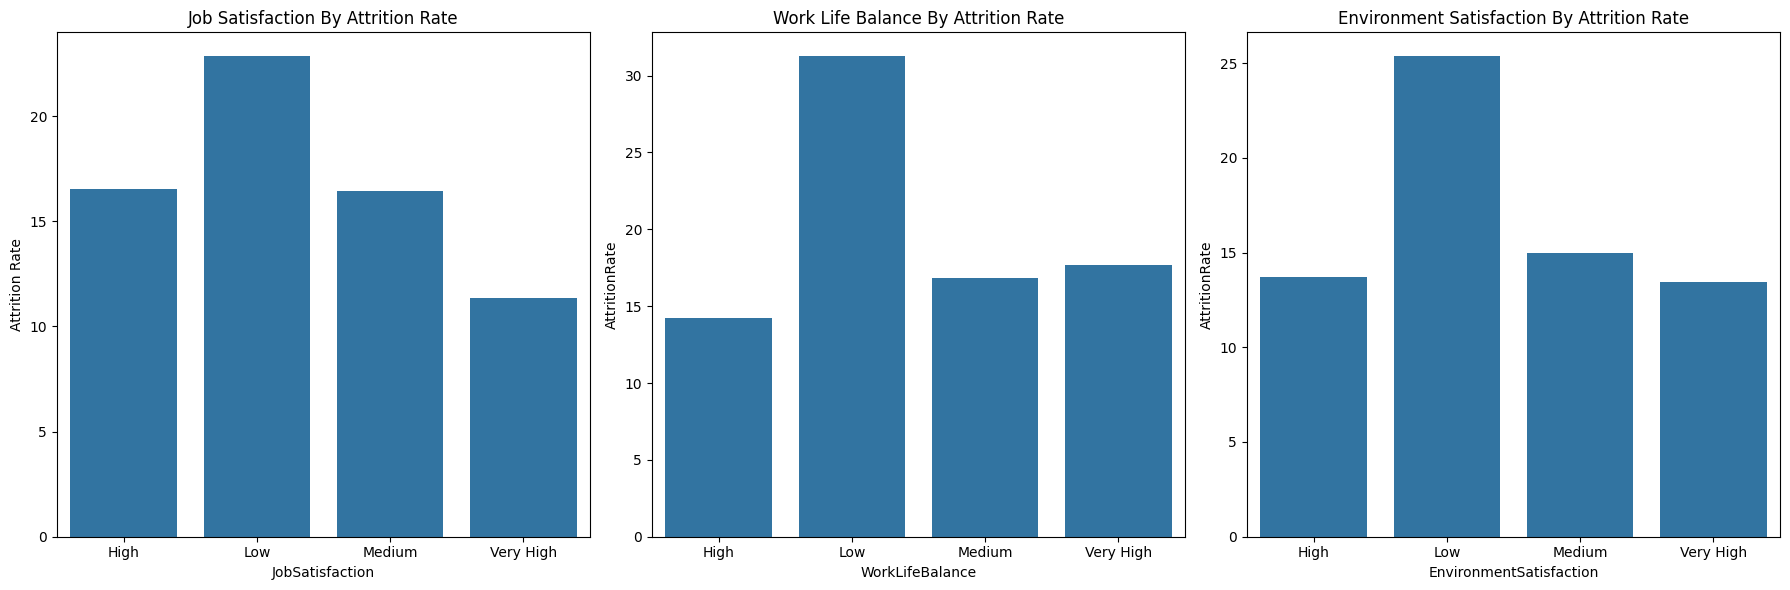

In [20]:
#OR Method-2  using barplot for each column separtely.

#Attrition Rate by JobSatisfaction,work-life Balance,Environment Satisfaction. 

fig,axes=plt.subplots(1,3,figsize=(18,6))
#job Statisfaction

attrition_JS=calculate_attrition_rate(df,'JobSatisfaction')

sns.barplot(data=attrition_JS,x='JobSatisfaction',y='AttritionRate',ax=axes[0])
axes[0].set_title('Job Satisfaction By Attrition Rate')
axes[0].set_xlabel('JobSatisfaction')
axes[0].set_ylabel('Attrition Rate')

attrition_wlb=calculate_attrition_rate(df,'WorkLifeBalance')

sns.barplot(data=attrition_wlb,x='WorkLifeBalance',y='AttritionRate',ax=axes[1])
axes[1].set_title('Work Life Balance By Attrition Rate')

attrition_ES=calculate_attrition_rate(df,'EnvironmentSatisfaction')
sns.barplot(data=attrition_ES,x='EnvironmentSatisfaction',y='AttritionRate',ax=axes[2])
axes[2].set_title('Environment Satisfaction By Attrition Rate')

plt.tight_layout()

plt.show()


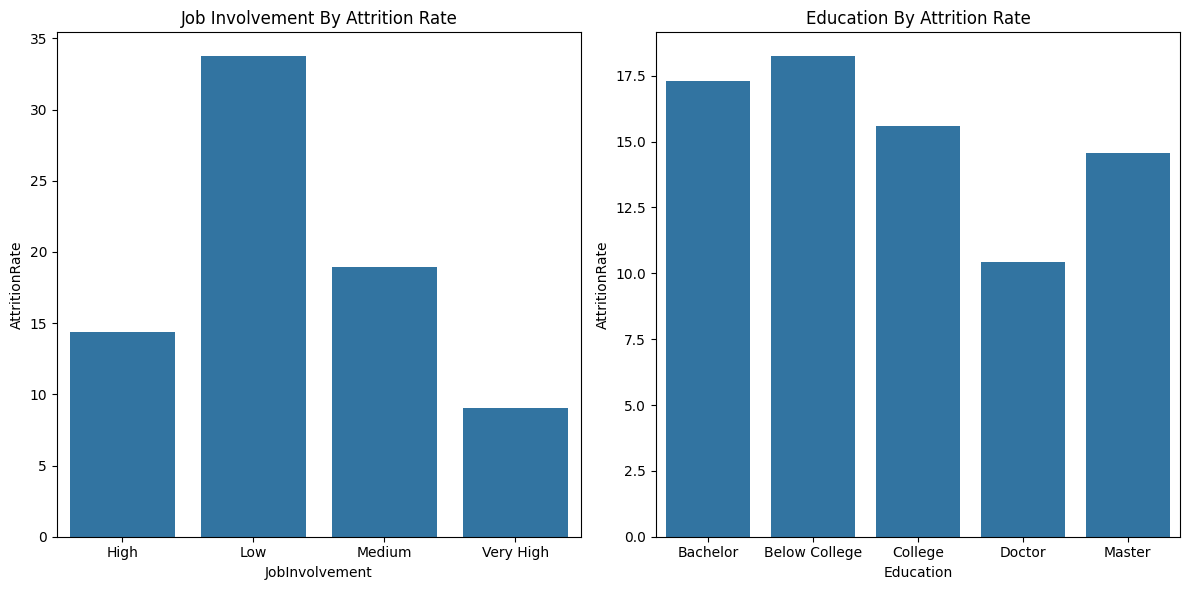

In [21]:
#Attrition rate by jobinvolvemet and Education

fig, axes=plt.subplots(1,2,figsize=(12,6))

JI_attrition=calculate_attrition_rate(df,'JobInvolvement')
sns.barplot(data=JI_attrition,x='JobInvolvement',y='AttritionRate',ax=axes[0])
axes[0].set_title('Job Involvement By Attrition Rate')

Edu_attrition=calculate_attrition_rate(df,'Education')
sns.barplot(data=Edu_attrition,x='Education',y='AttritionRate',ax=axes[1])
axes[1].set_title('Education By Attrition Rate')

plt.tight_layout()
plt.show()

In [22]:
#Breakdown of distance from home by role and attrition.
dist_jobrole=df.groupby('JobRole')['DistanceFromHome'].mean().reset_index()

print(dist_jobrole)   

                     JobRole  DistanceFromHome
0  Healthcare Representative          9.786260
1            Human Resources          8.173077
2      Laboratory Technician          9.409266
3                    Manager          8.029412
4     Manufacturing Director          9.482759
5          Research Director          8.437500
6         Research Scientist          9.013699
7            Sales Executive          9.659509
8       Sales Representative          8.662651


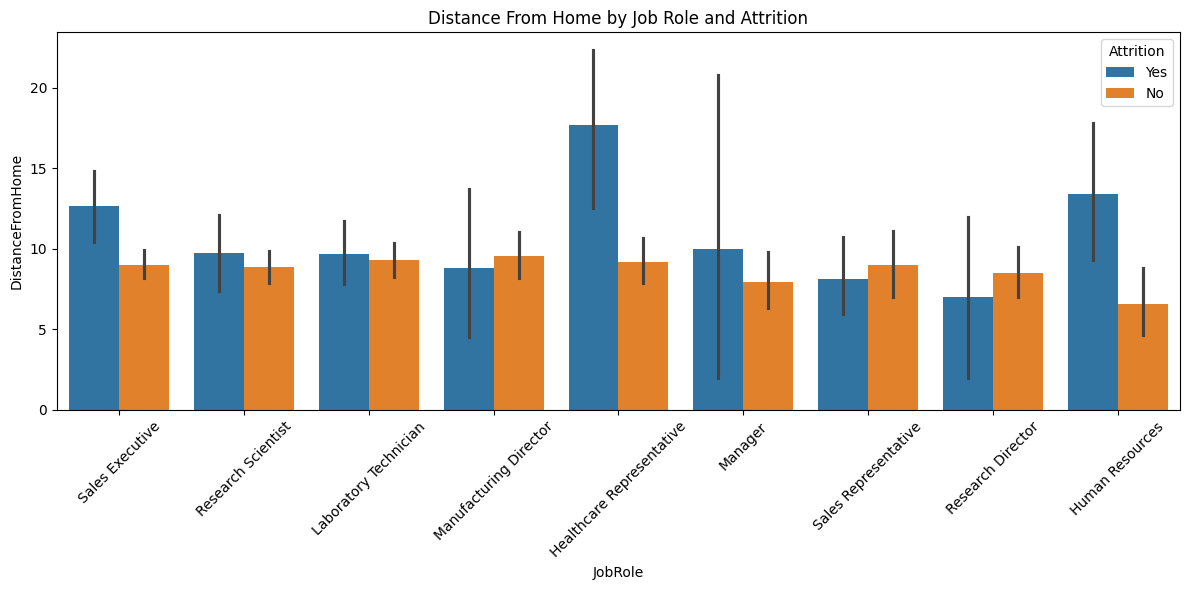

In [23]:
#let's Visualize it

plt.figure(figsize=(12,6))

sns.barplot(data=df,
            x='JobRole',
            y='DistanceFromHome',
            hue='Attrition')

plt.title('Distance From Home by Job Role and Attrition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation:**

The analysis shows that Healthcare Representative,Human Resources and sales Executive these job roles shows higher average distance from home and Employees living farther from office show higher attrition,indicating commuting distance may influence turnover.
